# Linear Regression

## Y = 2X + 3 最简线性回归 (重要)

实验目的：通过极简数据寻找 $w$ 和 $b$，复盘训练全流程，并建立防遗忘的笔记体系。
关键认知：验证集不改变参数，它改变的是我们的“决策”。

#### 1. 准备数据
 (2D Tensor 是必须的，所以用 .view(-1, 1))

In [ ]:
import torch

In [ ]:
# y = 2x + 3

X = torch.tensor([[1.0], [2.0], [3.0], [4.0]], dtype=torch.float32)
Y = torch.tensor([[5.0], [7.0], [9.0], [11.0]], dtype=torch.float32)


In [ ]:
import matplotlib.pyplot as plt

plt.plot(X.numpy(), Y.numpy())
plt.show()

### 2. 定义模型类 (继承 nn.Module)

🏗️ 结构定义我们使用 nn.Linear(1, 1)。
这在内部自动创建了两个变量：
- Weight ($w$): 初始值通常是随机的，目标是收敛到 2.0。
- Bias ($b$): 初始值随机，目标是收敛到 3.0。

注意：在 IBM 的语境中，如果你用训练集来测试这个模型的输出并记录误差，这个数组通常被命名为 test_error，即便它是在训练期间生成的。

In [ ]:
from torch import nn


class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        # 创建一个线性回归模型，内容包含w和b
        self.linear = nn.Linear(1, 1) # 输入维度1，输出维度1

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()

In [ ]:
print(model.state_dict())

### 3. 定义损失函数和优化器

In [ ]:

from torch import optim

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

train_losses = []

### 4. 训练循环 (Training Loop)

🔄 训练五步法 (必须肌肉记忆)
- 梯度清零：optimizer.zero_grad()。如果不清零，PyTorch 会累加之前的梯度。
- 前向传播：y_hat = model(X)。
- 计算损失：loss = criterion(y_hat, Y)。
- 反向传播：loss.backward()。这一步算出梯度。
- 更新参数：optimizer.step()。这一步根据学习率真正修改 $w$ 和 $b$。

In [ ]:

for epoch in range(10):
    # --- 核心五步法 ---
    optimizer.zero_grad()        # 1. 清零梯度 (擦黑板)
    y_hat = model(X)             # 2. 前向传播 (算预测值)
    loss = criterion(y_hat, Y)   # 3. 计算损失 (看错多少)
    loss.backward()              # 4. 反向传播 (算导数/梯度)
    optimizer.step()             # 5. 更新参数 (迈出一小步)

    train_losses.append(loss.item()) # 6.保存Loss值
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/500], Loss: {loss.item():.4f}')


### 5. 模型预测

🧪 验证与评估 (Minimize Validation Errors)
为什么我们需要在每个 Epoch 之后（或者训练完成后）进行验证？
- Early Stopping: 如果验证误差不再下降，停止训练。
- Change Hyperparameters: 如果验证误差高，我们需要手动修改学习率 $lr$ 或模型结构。

注意：在 with torch.no_grad(): 块内，模型不会更新任何参数。

In [ ]:
# 1. 将模型设为评估模式 (Evaluation Mode)
# 虽然简单的线性回归看不出区别，但在包含 Dropout 或 BatchNorm 的模型中这步至关重要
model.eval()

# 2. 准备测试集 (必须也是 2D Tensor)
X_test = torch.tensor([[5.0], [10.0], [20.0]], dtype=torch.float32)

# 3. 预测 (禁用梯度计算，这是预测时的标准姿势)
with torch.no_grad():
    predictions = model(X_test)

# 4. 查看结果
for i, x in enumerate(X_test):
    print(f"输入 x = {x.item():.1f}, 预测 y_hat = {predictions[i].item():.4f} (理论值: {2*x.item()+3})")

---

##  2 Stochastic Gradient Descent

In [ ]:
w = torch.tensor(-15.0, requires_grad=True)
b = torch.tensor(-10.0, requires_grad=True)

In [ ]:
X = torch.arange(-3, 3, 0.1).view(-1, 1)
f = -3 * X

In [ ]:
import matplotlib.pyplot as plt

plt.plot(X.numpy(), f.numpy())
plt.show()

In [ ]:
Y = f + 0.1 * torch.randn(X.size())
plt.plot(X.numpy(), Y.numpy())
plt.show()

In [ ]:
def forward(x):
    y = w * x + b
    return y


def criterion(yhat, y):
    return torch.mean((yhat - y) ** 2)

In [ ]:
lr = 0.1
for epoch in range(4):  # 4轮，4次完整遍历
    # 每个iteration计算一个样本的梯度
    for x, y in zip(X, Y):  # 每个数据点一次iteration或batch循环 zip(X,Y)是将X，Y配对
        yhat = forward(x)
        loss = criterion(yhat, y)
        loss.backward()
        w.data -= lr * w.grad.data
        b.data -= lr * b.grad.data
        w.grad.data.zero_()
        b.grad.data.zero_()

### 使用tensorflow实现SGD

In [ ]:
import tensorflow as tf
import numpy as np

# --- 1. 数据准备 (与PyTorch版本一致) ---
# 将 PyTorch 张量转换为 NumPy 或 TensorFlow 张量
X_np = np.arange(-3, 3, 0.1).reshape(-1, 1)  # ~60x1
f_np = -3 * X_np
Y_np = f_np + 0.1 * np.random.randn(*X_np.shape)

# 将 NumPy 数组转换为 TensorFlow 张量
X_tf = tf.constant(X_np, dtype=tf.float32)
Y_tf = tf.constant(Y_np, dtype=tf.float32)

# --- 2. 参数初始化 (手动设置初始值) ---
# 在 Keras 中，我们通常让层自己初始化，但为了匹配原例，可以手动设置
# 注意：TensorFlow/Keras 中，偏置项 b 默认是模型的一部分
initial_w = np.array([[-15.0]], dtype=np.float32)
initial_b = np.array([-10.0], dtype=np.float32)

# --- 3. 学习率 ---
lr = 0.1
## 🛠️ 模型定义
# Keras Sequential 模型用于线性回归
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        units=1,
        input_shape=(1,),  # 输入特征数量是 1
        name='LinearLayer'
    )
])

# 设置初始权重以匹配 PyTorch 示例的 w=-15.0 和 b=-10.0
model.get_layer('LinearLayer').set_weights([initial_w, initial_b])

## ⚙️ 编译模型 (定义优化器和损失函数)
model.compile(
    # 优化器：使用 SGD，并设置学习率
    optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
    # 损失函数：均方误差 (Mean Squared Error)，与 criterion(yhat, y) 对应
    loss='mse'
)

## 🏃 训练模型

# 将数据打包成 tf.data.Dataset 以便逐样本或逐批次训练
# 由于原 PyTorch 代码使用了 SGD (逐样本更新)，我们设置 batch_size=1
train_dataset = tf.data.Dataset.from_tensor_slices((X_tf, Y_tf)).batch(1)
print("开始训练 (Batch Size = 1 对应 SGD/逐样本更新)...")

history = model.fit(
    train_dataset,
    epochs=4,  # 训练轮次，与原代码 for epoch in range(4) 对应
    verbose=0  # 不打印过程，使输出更简洁
)

print("\n训练完成。")

# 打印最终参数
final_w, final_b = model.get_layer('LinearLayer').get_weights()
print(f"最终权重 w: {final_w.flatten()[0]:.4f}")
print(f"最终偏置 b: {final_b[0]:.4f}")

### 使用DataLoader

In [ ]:
from torch.utils.data import Dataset, DataLoader

class Data(Dataset):
    def __init__(self):
        self.x = torch.arange(-3, 3, 0.1).view(-1)
        self.y = -3 * self.x  + 1
        self.len = self.x.shape[0]
    def __getitem__(self, index):
        return self.x[index], self.y[index]
    def __len__(self):
        return self.len

dataset = Data()

trainloader = DataLoader(dataset, batch_size=1)
lr = 0.1
for x, y in trainloader:
    yhat = forward(x)
    loss = criterion(yhat, y)
    loss.backward()
    w.data -= lr * w.grad.data
    b.data -= lr * b.grad.data
    w.grad.data.zero_()
    b.grad.data.zero_()


---

## 3 Mini-Batch Gradient Descent

In [ ]:
from torch.utils.data import Dataset, DataLoader

class Data(Dataset):
    def __init__(self):
        self.x = torch.arange(-3, 3, 0.1).view(-1)
        self.y = -3 * self.x  + 1
        self.len = self.x.shape[0]
    def __getitem__(self, index):
        return self.x[index], self.y[index]
    def __len__(self):
        return self.len

dataset = Data()
# 2个数据一批
trainloader = DataLoader(dataset, batch_size=2)
lr = 0.1
LOSS = []
for x, y in trainloader:
    yhat = forward(x)
    loss = criterion(yhat, y)
    loss.backward()
    w.data -= lr * w.grad.data
    b.data -= lr * b.grad.data
    w.grad.data.zero_()
    b.grad.data.zero_()
    LOSS.append(loss.item())


---

## Multiple Linear Regression

 y = dot(x, w) + b
- x 代表特征向量 Feature Vector
- w 代表权重向量 Weight Vector
- b 仍是标量

In [ ]:

import torch
torch.manual_seed(1)

定义初始w，b。 ‼️注意这个两个值是初始化值， 并不是最终的真实值。

In [ ]:
w = torch.tensor([[2.0], [3.0]], requires_grad=True)
b = torch.tensor([[1.0]], requires_grad=True)

思考：
1. Torch.mm() 什么用的？
- torch.mm() 是 **Matrix Multiplication**（矩阵乘法） 的缩写。也就是**点乘**。
- 调用GPU并行计算，效率高

2. 为什么要这个地方定义向前传播？

In [ ]:
def forward(x):
    yhat = torch.mm(x, w) + b
    return yhat

思考：
在向前传播里面 w,x和b都输入进去了， 当然向前传播一次就能预测到是9，还需要训练模型干嘛，都知道公式了这不是作弊吗？（换句话说， 模型需要去猜w和b，为什么在向前传播时，就传递给它）

- 上面定义的w和b是随便给的初始值 并不是真正的w和b，而且在现实ml中， 很可能我没有人知道真实w，b，ai预测的越准， 说明w，b越接近真实值

**机器学习的哲言：**
- 训练的本质：利用 loss.backward() 产生的梯度，像拧螺丝一样，一点点地把 $w$ 和 $b$ 从随机数调整到能算出 真实 的值。
- 向前传播 (Forward)：不是为了得到正确答案，而是为了衡量当前的无知
- 训练 (Training)：是一个“纠偏”的过程。我们通过已知的 $x$ 和 $y$（训练集），反向逼近未知的 $w$ 和 $b$。
- 成功标志：当模型在未见过的新数据上也能预测准确时，说明我们的参数已经抓住了现实世界的客观规律。

In [ ]:
x = torch.tensor([[1.0, 2.0]])
yhat = forward(x)
print("The result: ", yhat)

### Build Custom Modules

1. 制造参数

In [ ]:
class Data2D(Dataset):

    # Constructor
    def __init__(self):
        self.x = torch.zeros(20, 2)
        self.x[:, 0] = torch.arange(-1, 1, 0.1)
        self.x[:, 1] = torch.arange(-1, 1, 0.1)
        self.w = torch.tensor([[1.0], [1.0]])
        self.b = 1
        self.f = torch.mm(self.x, self.w) + self.b
        self.y = self.f + 0.1 * torch.randn((self.x.shape[0],1))
        self.len = self.x.shape[0]

    # Getter
    def __getitem__(self, index):
        return self.x[index], self.y[index]

    # Get Length
    def __len__(self):
        return self.len

data_set = Data2D()

In [ ]:
train_loader = DataLoader(dataset=data_set, batch_size=2)

// plot多维数据

In [ ]:
from torch import nn
import torch
import numpy as np
import matplotlib.pyplot as plt


def Plot_2D_Plane(model, dataset, n=0):
    w1 = model.state_dict()['linear.weight'].numpy()[0][0]
    w2 = model.state_dict()['linear.weight'].numpy()[0][1]
    b = model.state_dict()['linear.bias'].numpy()

    # Data
    x1 = dataset.x[:, 0].view(-1, 1).numpy()
    x2 = dataset.x[:, 1].view(-1, 1).numpy()
    y = dataset.y.numpy()

    # Make plane
    X, Y = np.meshgrid(np.arange(x1.min(), x1.max(), 0.05), np.arange(x2.min(), x2.max(), 0.05))
    yhat = w1 * X + w2 * Y + b

    # Plotting
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(x1[:, 0], x2[:, 0], y[:, 0],'ro', label='y') # Scatter plot

    ax.plot_surface(X, Y, yhat) # Plane plot

    ax.set_xlabel('x1 ')
    ax.set_ylabel('x2 ')
    ax.set_zlabel('y')
    plt.title('estimated plane iteration:' + str(n))
    ax.legend()

    plt.show()

2. 定义模型

In [ ]:
class linear_regression(nn.Module):

    # Constructor
    def __init__(self, input_size, output_size):
        super(linear_regression, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    # Prediction function
    def forward(self, x):
        yhat = self.linear(x)
        return yhat


model = linear_regression(2, 1)

In [ ]:
print("The parameters: ", list(model.parameters()))

In [ ]:
print("The parameters: ", model.state_dict())

3. 定义优化器和loss函数

In [ ]:
print("Before Training: ")
Plot_2D_Plane(model, data_set)

4. 模型训练

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=0.1)
criterion = nn.MSELoss()

In [ ]:
LOSS = []
epochs = 100

def train_model(epochs):
    for epoch in range(epochs):
        for x,y in train_loader:
            yhat = model(x)
            loss = criterion(yhat, y)
            LOSS.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
train_model(epochs)

In [ ]:
print("After Training: ")
Plot_2D_Plane(model, data_set, epochs)

In [ ]:
plt.plot(LOSS)
plt.xlabel("Iterations ")
plt.ylabel("Cost/total loss ")

思考： 如何理解训练前、后的图和这张loss图？
第一图 - Before Training：
- 红点：是真实的训练数据 $y$。
- 浅蓝色平面：是模型根据随机初始化的 $w$ 和 $b$ 绘制出的“猜测结果”
- 现象：平面和红点完全不贴合，甚至方向都是反的。
- 结论：随机给的权重（比如 0.2347, -0.4707 等）根本预测不准，模型此时处于“瞎猜”阶段。

第二张图 - After Training：
- 现象：那个浅蓝色的平面现在精准地穿过了绝大多数红点。
- 本质：通过训练，PyTorch 已经自动调整了 $w$ 和 $b$。现在的平面方程已经非常接近你那个实验的目标方程（比如 $y = 2x_1 + 3x_2 + 1$）。
- 理解：模型已经“学会”了数据背后的规律。此时如果你输入一个新的 $x$（在平面范围内的），它预测出的 $y$ 就会非常准。

第三张图 - Loss Curve ：
- 横轴 (Iterations)：训练的轮次（0 到 1000 次）。
- 纵轴 (Cost/Total Loss)：预测值和真实值之间的“痛苦值”（差距）。
- 如何理解波动态势？
    - 整体趋势：你应该关注它的“底端”。随着时间推移，Loss 的最低点在不断下降，说明模型在变好。
    - 剧烈波动：图中那种密集的竖线说明你在使用 Stochastic Gradient Descent (SGD, 随机梯度下降)。因为每次只拿一个或一小块数据去更新，模型会像喝醉了一样乱撞，但总体是往低处走的。
    - 平稳期：当曲线不再明显下降，说明模型已经“尽力了”，参数已经达到了最优。

## Multi Output Linear Regression

公式：  y = wx + b
		- x 代表特征向量 Feature Vector ， 如，(x1,x2,x3)
		- w是特征矩阵， 注意这里是矩阵，因为每个y结果受一个权重向量的影响
		- y  代表多个目标值
		- b 是一个偏置向量

举例：以体重秤为例，测量值x1为压力感应值，x2=生物电阻抗值，目标值y1=体重，y2=体脂 y3=血糖  ，则权重微量w1=$[w_\text{(0,0),} w_\text{(0,1)}],b_0$影响y1的计算, w2=$[w_\text{(1,0),} w_\text{(1,1)}], b_1$影响y2值，w3=$[w_\text{(2,0),} w_\text{(2,1)}], b_2$影响y3的计算。


In [ ]:
from torch import nn
import torch

In [ ]:
torch.manual_seed(1)

In [ ]:
class linear_regression(nn.Module):
    def __init__(self,input_size,output_size):
        super(linear_regression,self).__init__()
        self.linear=nn.Linear(input_size,output_size)
    def forward(self,x):
        yhat=self.linear(x)
        return yhat

In [ ]:
model=linear_regression(1,10)
model(torch.tensor([1.0]))

In [ ]:
list(model.parameters())

In [ ]:
X=torch.tensor([[1.0],[1.0],[3.0]])
Yhat=model(X)
Yhat

思考： 为什么只有一个特征向量x，却可以接受输入X向量？
X向量是样本集合，不是多维，每个元素代表一个样本，每个样本输入模型，都会预测得到10个结果。

 ### training multi output linear regerssion

In [ ]:
from torch.utils.data import Dataset, DataLoader
class Data(Dataset):
    def __init__(self):
            self.x=torch.zeros(20,2)
            self.x[:,0]=torch.arange(-1,1,0.1)
            self.x[:,1]=torch.arange(-1,1,0.1)
            self.w=torch.tensor([ [1.0,-1.0],[1.0,3.0]])
            self.b=torch.tensor([[1.0,-1.0]])
            self.f=torch.mm(self.x,self.w)+self.b

            self.y=self.f+0.001*torch.randn((self.x.shape[0],1))
            self.len=self.x.shape[0]

    def __getitem__(self,index):

        return self.x[index],self.y[index]

    def __len__(self):
        return self.len
data_set=Data()

In [ ]:
class linear_regression(nn.Module):
    def __init__(self,input_size,output_size):
        super(linear_regression,self).__init__()
        self.linear=nn.Linear(input_size,output_size)
    def forward(self,x):
        yhat=self.linear(x)
        return yhat
model=linear_regression(2,2)

In [ ]:
from torch.utils.data import DataLoader
from torch import optim

optimizer = optim.SGD(model.parameters(), lr = 0.1)
criterion = nn.MSELoss()

In [ ]:
train_loader=DataLoader(dataset=data_set,batch_size=5)

In [ ]:
LOSS=[]

epochs=100

for epoch in range(epochs):
    for x,y in train_loader:
        #make a prediction
        yhat=model(x)
        #calculate the loss
        loss=criterion(yhat,y)
        #store loss/cost
        LOSS.append(loss.item())
        #clear gradient
        optimizer.zero_grad()
        #Backward pass: compute gradient of the loss with respect to all the learnable parameters
        loss.backward()
        #the step function on an Optimizer makes an update to its parameters
        optimizer.step()

In [ ]:
import matplotlib.pyplot as plt

plt.plot(LOSS)
plt.xlabel("iterations ")
plt.ylabel("Cost/total loss ")
plt.show()

### 逻辑回归

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [31]:

class plot_error_surfaces(object):

    # Constructor
    def __init__(self, w_range, b_range, X, Y, n_samples = 30, go = True):
        W = np.linspace(-w_range, w_range, n_samples)
        B = np.linspace(-b_range, b_range, n_samples)
        w, b = np.meshgrid(W, B)
        Z = np.zeros((30, 30))
        count1 = 0
        self.y = Y.numpy()
        self.x = X.numpy()
        for w1, b1 in zip(w, b):
            count2 = 0
            for w2, b2 in zip(w1, b1):
                Z[count1, count2] = np.mean((self.y - (1 / (1 + np.exp(-1*w2 * self.x - b2)))) ** 2)
                count2 += 1
            count1 += 1
        self.Z = Z
        self.w = w
        self.b = b
        self.W = []
        self.B = []
        self.LOSS = []
        self.n = 0
        if go == True:
            plt.figure()
            plt.figure(figsize=(7.5, 5))
            plt.axes(projection='3d').plot_surface(self.w, self.b, self.Z, rstride=1, cstride=1, cmap='viridis', edgecolor='none')
            plt.title('Loss Surface')
            plt.xlabel('w')
            plt.ylabel('b')
            plt.show()
            plt.figure()
            plt.title('Loss Surface Contour')
            plt.xlabel('w')
            plt.ylabel('b')
            plt.contour(self.w, self.b, self.Z)
            plt.show()


     # Setter
    def set_para_loss(self, model, loss):
        self.n = self.n + 1
        self.W.append(list(model.parameters())[0].item())
        self.B.append(list(model.parameters())[1].item())
        self.LOSS.append(loss)

    # Plot diagram
    def final_plot(self):
        ax = plt.axes(projection='3d')
        ax.plot_wireframe(self.w, self.b, self.Z)
        ax.scatter(self.W, self.B, self.LOSS, c='r', marker='x', s=200, alpha=1)
        plt.figure()
        plt.contour(self.w, self.b, self.Z)
        plt.scatter(self.W, self.B, c='r', marker='x')
        plt.xlabel('w')
        plt.ylabel('b')
        plt.show()

    # Plot diagram
    def plot_ps(self):
        plt.subplot(121)
        plt.ylim
        plt.plot(self.x, self.y, 'ro', label="training points")
        plt.plot(self.x, self.W[-1] * self.x + self.B[-1], label="estimated line")
        plt.plot(self.x, 1 / (1 + np.exp(-1 * (self.W[-1] * self.x + self.B[-1]))), label='sigmoid')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.ylim((-0.1, 2))
        plt.title('Data Space Iteration: ' + str(self.n))
        plt.show()
        plt.subplot(122)
        plt.contour(self.w, self.b, self.Z)
        plt.scatter(self.W, self.B, c='r', marker='x')
        plt.title('Loss Surface Contour Iteration' + str(self.n))
        plt.xlabel('w')
        plt.ylabel('b')

def PlotStuff(X, Y, model, epoch, leg=True):
    plt.plot(X.numpy(), model(X).detach().numpy(), label=('epoch ' + str(epoch)))
    plt.plot(X.numpy(), Y.numpy(), 'r')
    if leg == True:
        plt.legend()
    else:
        pass

In [32]:
torch.manual_seed(0)

In [33]:
class Data(Dataset):

    # Constructor
    def __init__(self):
        self.x = torch.arange(-1, 1, 0.1).view(-1, 1)
        self.y = torch.zeros(self.x.shape[0], 1)
        self.y[self.x[:, 0] > 0.2] = 1
        self.len = self.x.shape[0]

    # Getter
    def __getitem__(self, index):
        return self.x[index], self.y[index]

    # Get Length
    def __len__(self):
        return self.len

In [34]:
data_set = Data()

In [35]:
class logistic_regression(nn.Module):

    # Constructor
    def __init__(self, n_inputs):
        super(logistic_regression, self).__init__()
        self.linear = nn.Linear(n_inputs, 1)

    # Prediction
    def forward(self, x):
        yhat = torch.sigmoid(self.linear(x))
        return yhat

In [36]:
model = logistic_regression(1)

In [37]:
model.state_dict() ['linear.weight'].data[0] = torch.tensor([[-5]])
model.state_dict() ['linear.bias'].data[0] = torch.tensor([[-10]])

In [38]:
print("The parameters: ", model.state_dict())

The parameters:  OrderedDict([('linear.weight', tensor([[-5.]])), ('linear.bias', tensor([-10.]))])


<Figure size 640x480 with 0 Axes>

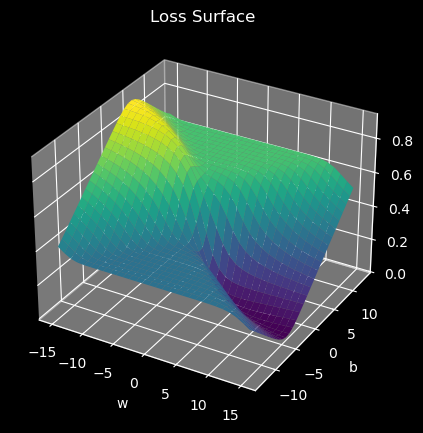

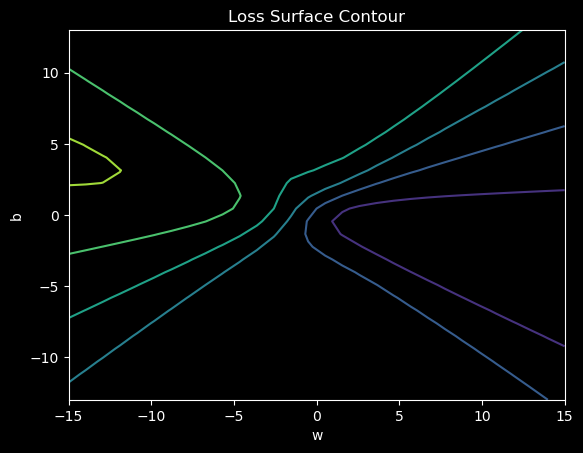

In [39]:

get_surface = plot_error_surfaces(15, 13, data_set[:][0], data_set[:][1], 30)

#### 注意‼️观察使用 MSE和使用crossentropy的区别


In [52]:
trainloader = DataLoader(dataset=data_set, batch_size=3)
criterion_rms = nn.MSELoss()

# criterion_rms = nn.BCELoss()

learning_rate = 2
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

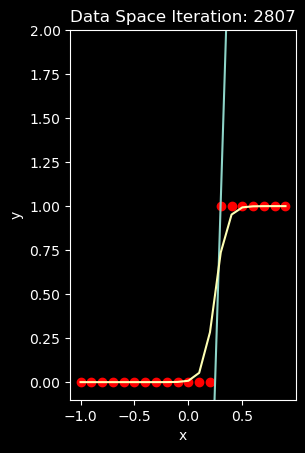

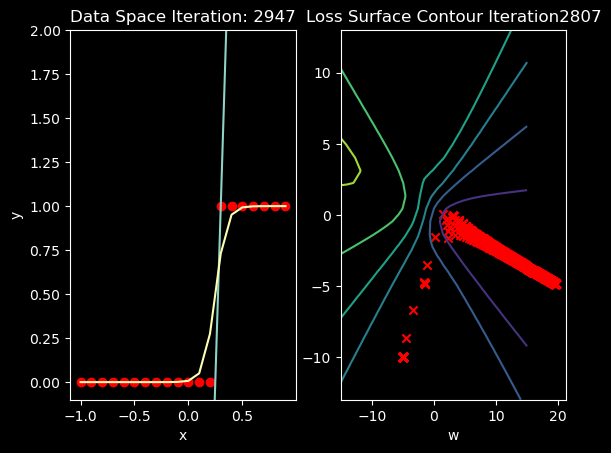

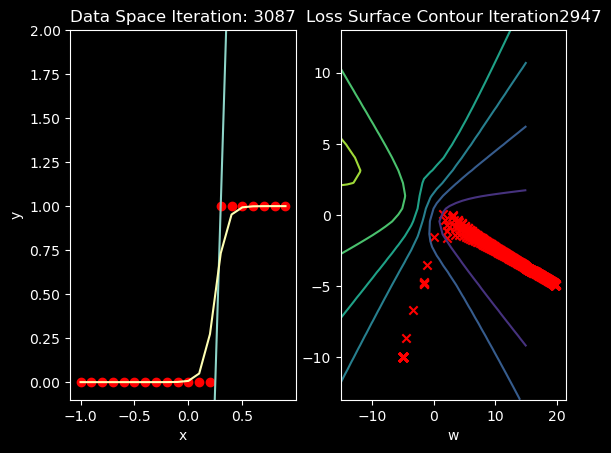

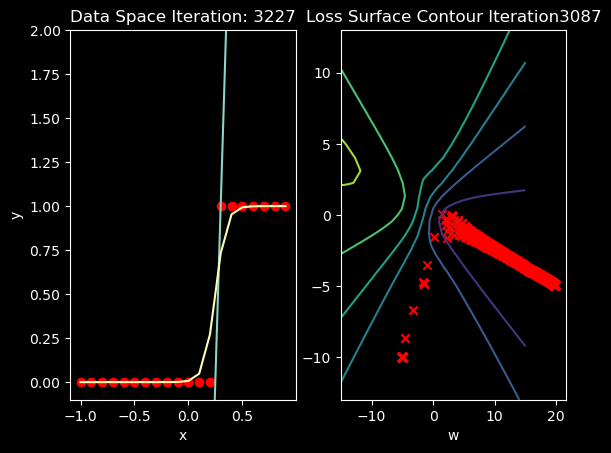

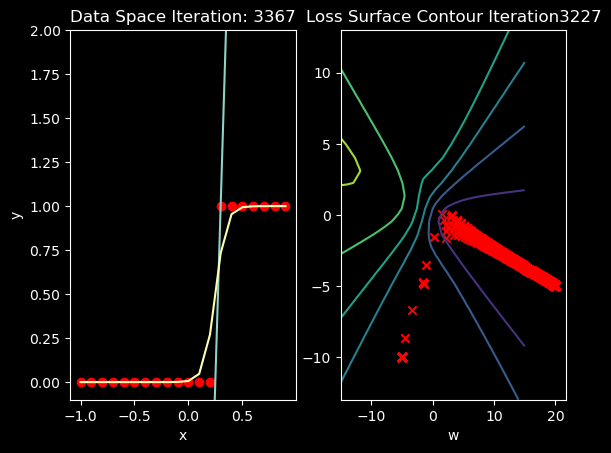

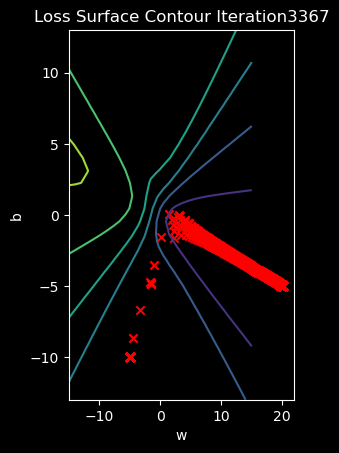

In [53]:
def train_model(epochs):
    for epoch in range(epochs):
        for x, y in trainloader:
            optimizer.zero_grad()
            yhat = model(x)
            loss = criterion_rms(yhat, y)
            loss.backward()
            optimizer.step()
            get_surface.set_para_loss(model, loss.tolist())
        if epoch % 20 == 0:
            get_surface.plot_ps()

train_model(100)

In [42]:
yhat = model(data_set.x)
label = yhat > 0.5
print("The accuracy: ", torch.mean((label == data_set.y.type(torch.ByteTensor)).type(torch.float)))

The accuracy:  tensor(0.6500)
